In [1]:
# Cell 1 – Setup
print("Cell 1 – Setup:")
from tensorflow.keras.models import load_model
from tensorflow.keras.losses import MeanSquaredError
import numpy as np
import json
import os
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive', force_remount=True)

# Load denoised model with compile=False to avoid 'mse' issue
model_path = '/content/drive/MyDrive/C3I-Internship-Work/Programs/MaritimeAnomalyDetection/models/denoised_norwegian_attention_gru_ae.h5'
model = load_model(model_path, compile=False)

# Re-compile manually
model.compile(optimizer='adam', loss=MeanSquaredError())

# Load sequences
seq_path = '/content/drive/MyDrive/C3I-Internship-Work/Programs/MaritimeAnomalyDetection/features/norwegian_sequences.npy'
X = np.load(seq_path)
print(f"Loaded {X.shape[0]} windows of shape {X.shape[1:]}")

# Load threshold
with open('/content/drive/MyDrive/C3I-Internship-Work/Programs/MaritimeAnomalyDetection/models/norwegian_threshold.json') as f:
    threshold = json.load(f)['threshold']
print(f"🔔 Using MSE threshold = {threshold:.6f}")

Cell 1 – Setup:
Mounted at /content/drive
Loaded 875 windows of shape (20, 7)
🔔 Using MSE threshold = 0.005735


In [2]:
# Cell 2 – Compute Reconstruction Errors
print("Cell 2 – Compute Reconstruction Errors:")
from tqdm import tqdm
import pandas as pd

# Reconstruct
recon = model.predict(X, verbose=1)

# Compute MSE per window
mse = np.mean((X - recon) ** 2, axis=(1, 2))
is_anomaly = (mse > threshold).astype(int)

# Compile results
df_results = pd.DataFrame({
    'window_idx': np.arange(len(X)),
    'recon_mse': mse,
    'is_anomaly': is_anomaly
})

# Save results
results_dir = '/content/drive/MyDrive/C3I-Internship-Work/Programs/MaritimeAnomalyDetection/results'
os.makedirs(results_dir, exist_ok=True)
results_path = os.path.join(results_dir, 'norwegian_anomaly_windows.csv')
df_results.to_csv(results_path, index=False)

print(f"Total windows: {len(X)}, anomalies flagged: {df_results['is_anomaly'].sum()}")
print(f"\n✅ Anomaly windows written to {results_path}")
df_results.head()

Cell 2 – Compute Reconstruction Errors:
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step
Total windows: 875, anomalies flagged: 43

✅ Anomaly windows written to /content/drive/MyDrive/C3I-Internship-Work/Programs/MaritimeAnomalyDetection/results/norwegian_anomaly_windows.csv


,window_idx,recon_mse,is_anomaly
0,0,0.000066,0
1,1,0.000043,0
2,2,0.000042,0
3,3,0.000037,0
4,4,0.000029,0


Cell 3: Visualize the Anomalies:


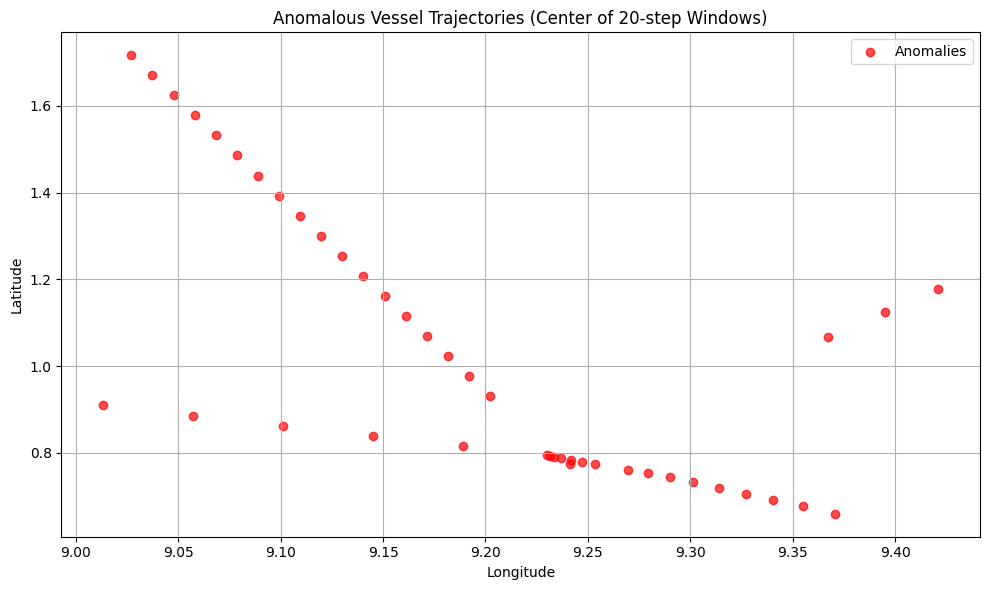

In [3]:
# Cell 3: Visualize the Anomalies
print("Cell 3: Visualize the Anomalies:")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load anomaly flags and sequences
anom_df = pd.read_csv('/content/drive/MyDrive/C3I-Internship-Work/Programs/MaritimeAnomalyDetection/results/norwegian_anomaly_windows.csv')
X = np.load('/content/drive/MyDrive/C3I-Internship-Work/Programs/MaritimeAnomalyDetection/features/norwegian_sequences.npy')

# Get lat/lon from the center of each anomalous window
lat_idx, lon_idx = 0, 1  # delta_lat, delta_lon
anom_windows = anom_df[anom_df['is_anomaly'] == 1]['window_idx'].values

lat_centers = []
lon_centers = []
for idx in anom_windows:
    window = X[idx]
    lat_center = np.cumsum(window[:, lat_idx]).mean()
    lon_center = np.cumsum(window[:, lon_idx]).mean()
    lat_centers.append(lat_center)
    lon_centers.append(lon_center)

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(lon_centers, lat_centers, c='red', label='Anomalies', alpha=0.7)
plt.title("Anomalous Vessel Trajectories (Center of 20-step Windows)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [4]:
# Cell 4 – Save anomaly results
print("Cell 4 – Save anomaly results:")
import pandas as pd
import os
os.makedirs('/content/drive/MyDrive/C3I-Internship-Work/Programs/MaritimeAnomalyDetection/results', exist_ok=True)

df = pd.DataFrame({
    'window_idx':    np.arange(len(mse)),
    'recon_mse':     mse,
    'is_anomaly':    is_anomaly.astype(int)
})
out_path = '/content/drive/MyDrive/C3I-Internship-Work/Programs/MaritimeAnomalyDetection/results/norwegian_anomaly_windows.csv'
df.to_csv(out_path, index=False)
print(f"✅ Anomaly windows written to {out_path}")
df.head()

Cell 4 – Save anomaly results:
✅ Anomaly windows written to /content/drive/MyDrive/C3I-Internship-Work/Programs/MaritimeAnomalyDetection/results/norwegian_anomaly_windows.csv


,window_idx,recon_mse,is_anomaly
0,0,0.000066,0
1,1,0.000043,0
2,2,0.000042,0
3,3,0.000037,0
4,4,0.000029,0


In [11]:
# Cell 4 – Ensure dynamic_thresholding.py defines the class
%%bash
cat > /content/drive/MyDrive/C3I-Internship-Work/Programs/MaritimeAnomalyDetection/dynamic_thresholding.py << 'EOF'
import numpy as np

class DynamicThresholdCalculator:
    """
    Simple dynamic-threshold calculator based on percentiles.
    - Collects a list of 'normal' error values.
    - Computes a threshold at the desired percentile.
    - Flags any future error above that threshold.
    """
    def __init__(self, window_size: int, percentile: float = 95.0):
        self.window_size = window_size
        self.percentile = percentile
        self.errors = []

    def add_normal_errors(self, errors):
        """
        Seed the calculator with historical 'normal' errors.
        """
        # Clip or pad to window_size if you like; here we just store all.
        self.errors = list(errors)

    def get_threshold(self) -> float:
        """
        Compute and return the current threshold (percentile of stored errors).
        """
        return float(np.percentile(self.errors, self.percentile))

    def detect_anomalies(self, errors):
        """
        Given a list of new errors, return a list of bools indicating
        which ones exceed the threshold.
        """
        thr = self.get_threshold()
        return [ (e > thr) for e in errors ]
EOF

echo "✅ Written dynamic_thresholding.py module with DynamicThresholdCalculator"

✅ Written dynamic_thresholding.py module with DynamicThresholdCalculator


In [12]:
# Cell 5 – Apply Dynamic Thresholding (fixed)
print("Cell 5 – Apply Dynamic Thresholding:")

import sys, importlib
from pathlib import Path
import pandas as pd

# ─── 0) Load your rule-based analysis results CSV ───────────────────────────────
proj_path   = '/content/drive/MyDrive/C3I-Internship-Work/Programs/MaritimeAnomalyDetection'
csv_path    = Path(proj_path) / 'results' / 'threat_analysis_results.csv'
if not csv_path.exists():
    raise FileNotFoundError(f"{csv_path} not found! Run 9.rule_based_layer.ipynb first.")
df_results  = pd.read_csv(csv_path)
test_results = [
    {
        'vessel_id':        row['vessel_id'],
        'overall_risk_score': row['overall_risk_score']
    }
    for _, row in df_results.iterrows()
]

print(f"🔍 Loaded {len(test_results)} vessels from rule‑based CSV")

# ─── 1) Ensure your module is importable ──────────────────────────────────────
if proj_path not in sys.path:
    sys.path.append(proj_path)
import dynamic_thresholding
importlib.reload(dynamic_thresholding)
from dynamic_thresholding import DynamicThresholdCalculator

# ─── 2) Dynamic threshold helper ─────────────────────────────────────────────
def apply_dynamic_thresholding_to_rule_results(test_results, percentile=85):
    print(f"🔍 Applying dynamic thresholding (percentile={percentile}) to {len(test_results)} vessels…")
    risk_scores = [r['overall_risk_score'] for r in test_results]

    dt = DynamicThresholdCalculator(window_size=len(test_results), percentile=percentile)
    dt.add_normal_errors(risk_scores)
    thr = dt.get_threshold()
    flags = dt.detect_anomalies(risk_scores)

    updated = []
    cnt = 0
    for i, res in enumerate(test_results):
        res['is_dynamic_anomaly'] = bool(flags[i])
        res['dynamic_threshold']  = thr
        if res['is_dynamic_anomaly']:
            cnt += 1
            print(f"  🚨 {res['vessel_id']} flagged (risk {res['overall_risk_score']:.3f} > {thr:.3f})")
        updated.append(res)

    print(f"\n✅ Dynamic thresholding complete: {cnt}/{len(test_results)} flagged (threshold={thr:.4f})")
    return updated, dt

# ─── 3) Run the dynamic thresholding ─────────────────────────────────────────
test_results, threshold_calculator = apply_dynamic_thresholding_to_rule_results(test_results, percentile=85)

# ─── 4) (Optional) Export combined results ────────────────────────────────────
out_dir = Path(proj_path) / 'results'
out_dir.mkdir(exist_ok=True, parents=True)
df_export = pd.DataFrame(test_results)
csv_out = out_dir / 'norwegian_rule_dynamic_results.csv'
df_export.to_csv(csv_out, index=False)
print(f"💾 Combined results saved to {csv_out}")


Cell 5 – Apply Dynamic Thresholding:
🔍 Loaded 20 vessels from rule‑based CSV
🔍 Applying dynamic thresholding (percentile=85) to 20 vessels…
  🚨 SMUGGLER_001 flagged (risk 0.333 > 0.050)
  🚨 SMUGGLER_002 flagged (risk 0.333 > 0.050)
  🚨 SMUGGLER_003 flagged (risk 0.333 > 0.050)

✅ Dynamic thresholding complete: 3/20 flagged (threshold=0.0500)
💾 Combined results saved to /content/drive/MyDrive/C3I-Internship-Work/Programs/MaritimeAnomalyDetection/results/norwegian_rule_dynamic_results.csv
